# Import

In [1]:
%matplotlib inline

import sys
import datacube
import skimage.exposure
import geopandas as gpd
import matplotlib.pyplot as plt
from IPython.display import Image
from IPython.core.display import Video
import xarray as xr
import numpy as np

from matplotlib import colors as mcolours

sys.path.insert(1, "../Tools/")
from dea_tools.bandindices import calculate_indices
from dea_tools.plotting import xr_animation, rgb, display_map
from dea_tools.landcover import plot_land_cover, lc_animation


# Connect to dev sandbox database

In [2]:
dc = datacube.Datacube(app="lc3_vs_lc2")

# Display variable names of LC collections

In [3]:
# display collections' variable names (i.e., measurements)

lc_2_name = "ga_ls_landcover_class_cyear_2"
lc_3_name = "ga_ls_landcover_class_cyear_3"

measurements = dc.list_measurements()

for product in [lc_2_name, lc_3_name]:
    print(f'{product}\n')
    display(measurements.loc[product])
    print('\n\n')

ga_ls_landcover_class_cyear_2



,name,dtype,units,nodata,aliases,flags_definition
measurement,,,,,,
level3,level3,uint8,1,0,NaN,NaN
lifeform_veg_cat_l4a,lifeform_veg_cat_l4a,uint8,1,0,[lifeform],NaN
canopyco_veg_cat_l4d,canopyco_veg_cat_l4d,uint8,1,0,[vegetation_cover],NaN
watersea_veg_cat_l4a_au,watersea_veg_cat_l4a_au,uint8,1,0,[water_seasonality],NaN
waterstt_wat_cat_l4a,waterstt_wat_cat_l4a,uint8,1,0,[water_state],NaN
inttidal_wat_cat_l4a,inttidal_wat_cat_l4a,uint8,1,0,[intertidal],NaN
waterper_wat_cat_l4d_au,waterper_wat_cat_l4d_au,uint8,1,0,[water_persistence],NaN
baregrad_phy_cat_l4d_au,baregrad_phy_cat_l4d_au,uint8,1,0,[bare_gradation],NaN
level4,level4,uint8,1,0,[full_classification],NaN





ga_ls_landcover_class_cyear_3



,name,dtype,units,nodata,aliases,flags_definition
measurement,,,,,,
level3,level3,uint8,1,255,NaN,NaN
level4,level4,uint8,1,255,[full_classification],NaN


# Define colour palette

### Level 3 visualisation 

The Level 3 classification contains six base classes: 

* <strong>111: Cultivated terrestrial vegetation</strong>  
Cultivated vegetation is vegetation that has been changed by human influence, such as planted crops or improved pasture. This is different from areas left to minor grazing or fallow.
* <strong>112: Natural terrestrial vegetation</strong>  
Natural vegetation is vegetation that has not been changed by human influence. This includes native forests as well as pastures or paddocks left unchanged for the year. It does not identify whether the vegetation is native or otherwise.
* <strong>124: Natural aquatic vegetation</strong>  
Aquatic vegetation is vegetation that gets regularly inundated with water. Mangroves are the main type of aquatic vegetation featured in DEA Land Cover.
* <strong>215: Artificial surface</strong>  
Artificial surfaces are human-made, unvegetated areas. This includes the roofs of houses, concrete areas, road surfaces and other similar surfaces that we associate with civilisation.
* <strong>216: Natural bare surface</strong>  
Natural bare surface is mostly soil. It is very likely that there is still vegetation in the area, but it is dominated by soil.
* <strong>220: Water</strong>  
Water captures terrestrial and coastal open water such as dams, lakes, large rivers and the coastal and near-shore zone. 

To plot the `level3` data, we will use the `plot_layer()` function. 
The `plot_layer()` function allows you to define your own colour map as shown in the cell below. 
The keys respond to the Level 3 classifications, and the values are colour specifications (red, green, blue, alpha) and labels to be used in the legend.

In [4]:
# Define a colour scheme for the Level 3
LEVEL3_COLOUR_SCHEME = {
    0: (255, 255, 255, 255, "No Data"),
    111: (172, 188, 45, 255, "Cultivated terrestrial vegetation"),
    112: (14, 121, 18, 255, "Natural terrestrial vegetation"),
    124: (30, 191, 121, 255, "Natural aquatic vegetation"),
    215: (218, 92, 105, 255, "Artificial surface"),
    216: (243, 171, 105, 255, "Natural bare surface"),
    220: (77, 159, 220, 255, "Water"),
}


# generate cmap
colour_arr = []

for key, value in LEVEL3_COLOUR_SCHEME.items():
        colour_arr.append(np.array(value[:-2]) / 255)

bounds = list(LEVEL3_COLOUR_SCHEME)
bounds.append(255)
level_3_cmap = mcolours.ListedColormap(colour_arr)
level_3_norm = mcolours.BoundaryNorm(np.array(bounds) - 0.1, level_3_cmap.N)

# Load LC products

In [5]:
def query_comparison_single_year(lat, 
                                 lon, 
                                 buffer_size, 
                                 year):

    '''
    Generates dc.load() query for square buffers around coordinates of interest
    '''
    
    lat_range = (lat - buffer_size, lat + buffer_size)
    lon_range = (lon - buffer_size, lon + buffer_size)

    query = {
            "y": lat_range,
            "x": lon_range,
            "time": str(year),
            }

    return query


In [6]:
# define query

query = query_comparison_single_year(lat = -18.10, 
                                     lon = 122.32, 
                                     buffer_size = 0.2, # WGS84 (0.2 == ~ 20km)
                                     year = 2017,
                                    )

In [7]:
# LC collection 2
lc_2 = dc.load(
    product=lc_2_name,
    output_crs="EPSG:3577",
    measurements=[
        "level3",
        "level4",
    ],
    resolution=(-25, 25),
    **query
)


# LC collection 3
lc_3 = dc.load(
    product=lc_3_name,
    output_crs="EPSG:3577",
    measurements=[
        "level3",
        "level4",
    ],
    resolution=(-25, 25),
    **query
)

In [8]:
# concatenate the two collections into one dataset
# the dates reported in collection 3 are the 1st or the 2nd July, while collection 2 uses the 1st January
# thus, concatenating them across time dimension will place collection 2 in the first time step, and collection 3 in the second time step

combined_lc = xr.concat([lc_2, lc_3], dim='time')
combined_lc

<xarray.Dataset> Size: 14MB
Dimensions:      (time: 2, y: 1895, x: 1824)
Coordinates:
  * time         (time) datetime64[ns] 16B 2017-01-01 2017-07-02T11:59:59.999999
  * y            (y) float64 15kB -1.948e+06 -1.948e+06 ... -1.996e+06
  * x            (x) float64 15kB -1.046e+06 -1.046e+06 ... -1.001e+06
    spatial_ref  int32 4B 3577
Data variables:
    level3       (time, y, x) uint8 7MB 220 220 220 220 220 ... 112 112 112 112
    level4       (time, y, x) uint8 7MB 101 101 101 101 101 ... 34 34 34 34 34
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

# Create animation

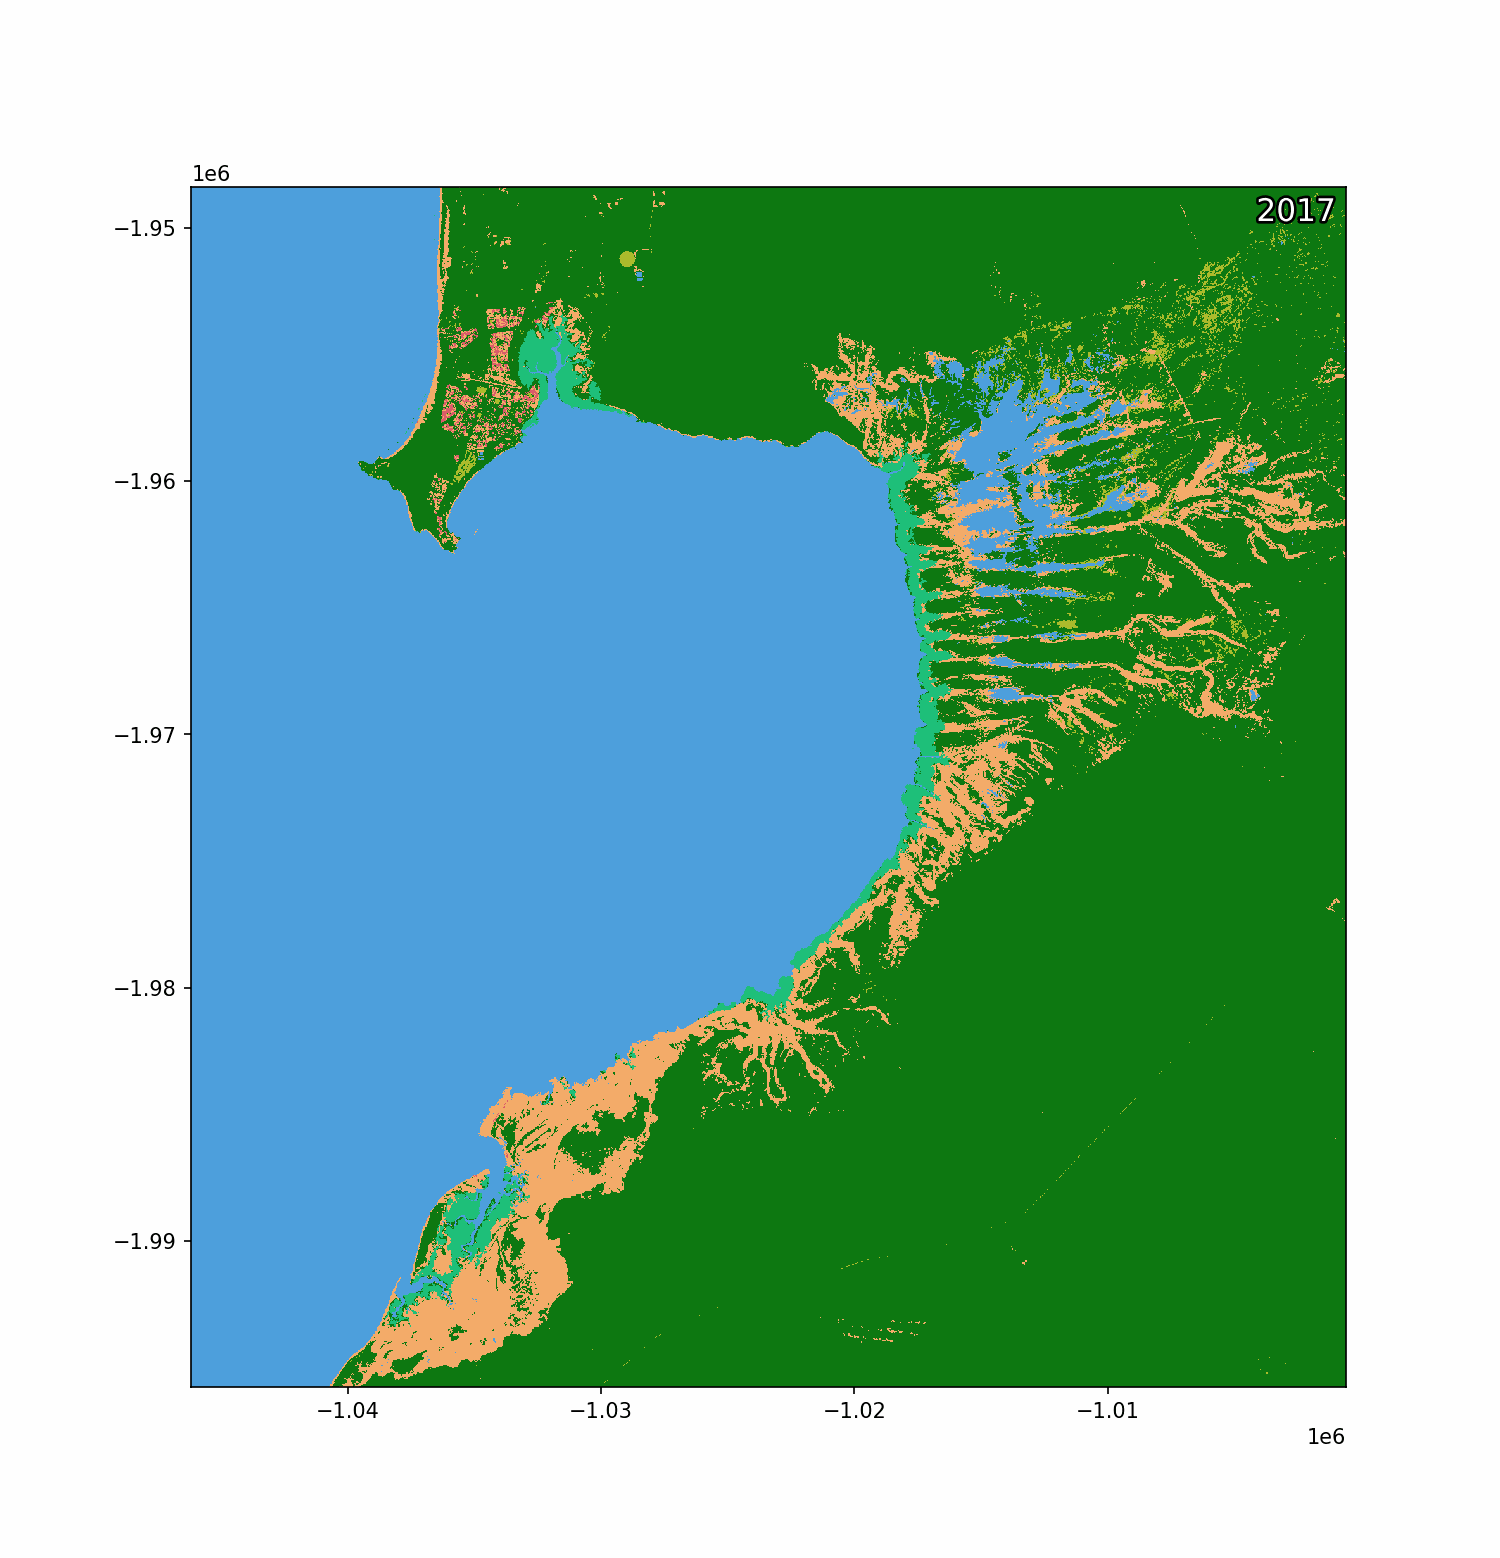

In [9]:
lc_animation(
        combined_lc.level3,
        file_name="animated_timeseries",
        stacked_plot=False,
        colour_bar=False,
        animation_interval=500,
        width_pixels=10,
        dpi=150,
        font_size=15,
        label_ax=True)

Exporting animation to animated_timeseries.gif


  0%|          | 0/2 (0.0 seconds remaining at ? frames/s)

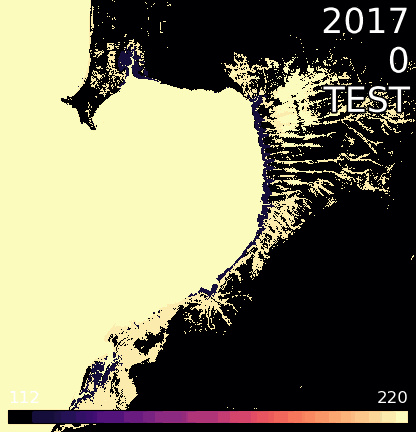

In [10]:

xr_animation(
    ds=combined_lc,
    bands=["level3"],
    output_path="animated_timeseries.gif",
    interval=500,
    width_pixels=300,
    show_date='%Y',
    show_text=[f'{str(i)}\nTEST' for i in range(len(combined_lc.time))],
    percentile_stretch=(0.01, 0.99),
    annotation_kwargs={"fontsize": 25},
    
)

# Plot animation
plt.close()
display(Image(filename="animated_timeseries.gif"))